In [3]:
import matplotlib.pyplot as plt

import PIL

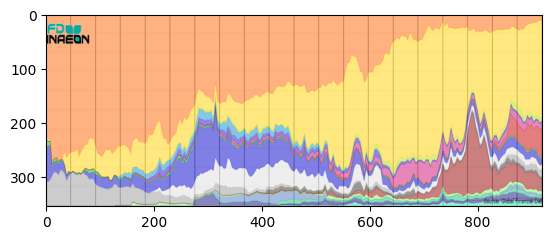

In [4]:
file = "data/market_cap_graph.png"

img = PIL.Image.open(file)

# crop the image to just the graph area (adjust these values based on your image)
cropped_img = img.crop((45, 21, 965, 376))  # (left, upper, right, lower)
# cropped_img = img.crop((900, 300, 966, 376))  # (left, upper, right, lower)

i = plt.imshow(cropped_img)

In [5]:
cropped_img.show()

C:\Users\CallumDavidson\AppData\Local\Temp\ipykernel_32516\4225855863.py:23: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  pixels = list(cropped_img.getdata())


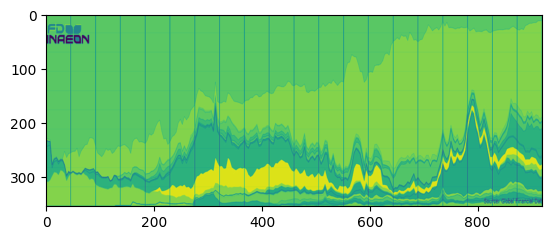

In [7]:
data_range = (1782, 2022)

x_pixels = cropped_img.width

# Map pixel x-coordinates to years
def pixel_to_year(x):
    return (data_range[0] + (x / (x_pixels - 1)) * (data_range[1] - data_range[0]))

pixel_years = {x: round(pixel_to_year(x)) for x in range(x_pixels)}

country_colors = {
    "US": "#fee87f",
    "UK": "#ffb180",
    "DE": "#eeeeee",
    "FR": "#807fe5",
    "JP": "#cb7f7f",
}
# country_colors = {k: PIL.ImageColor.getrgb(v) for k, v in country_colors.items()}

# Now you can use pixel_years to find the corresponding year for any x-coordinate in the cropped image

# construct a bitmap of hex colors for each pixel in the cropped image
pixels = list(cropped_img.getdata()) 
# filter alpha
pixels = [pixel[:3] for pixel in pixels]
pixels_test = [sum(pixel)/255*3 for pixel in pixels]  # convert to grayscale
pixels = ['#%02x%02x%02x' % p for p in pixels]

width, height = img.size
import numpy as np
hex_array_2d = np.array(pixels).reshape(cropped_img.size[1], cropped_img.size[0])
plt.imshow(np.array(pixels_test).reshape(cropped_img.size[1], cropped_img.size[0]))

In [8]:
def get_percentages_for_year(year, hex_array_2d, pixel_years, country_colors):
    # Find the x-coordinate for the given year
    x = None
    x_coordinates = []
    for x_coord, yr in pixel_years.items():
        if yr == year:
            x_coordinates.append(x_coord)
    if not x_coordinates:
        return None  # Year not found in pixel mapping
    out = {}

    # transpose the hex_array_2d to get columns as lists
    # hex_array_2d_T = list(map(list, zip(*hex_array_2d)))
    out = {c: [] for c in country_colors.keys()}
    for x in x_coordinates:
        column = hex_array_2d[:, x]
        for country, color in country_colors.items():
            count = np.sum(column == color)
            out[country].append(count)
    averages = {country: np.mean(counts) if counts else 0 for country, counts in out.items()}
    percentages = {country: ( avg / len(hex_array_2d)) for country, avg in averages.items()}
    
    return percentages

get_percentages_for_year(1900, hex_array_2d, pixel_years, country_colors)

{'US': np.float64(0.19577464788732393),
 'UK': np.float64(0.31619718309859157),
 'DE': np.float64(0.07394366197183098),
 'FR': np.float64(0.06056338028169014),
 'JP': np.float64(0.0)}

C:\Users\CallumDavidson\AppData\Local\Temp\ipykernel_32516\4014650735.py:8: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  df = pl.DataFrame(data, schema=["Year", "Percentages"])


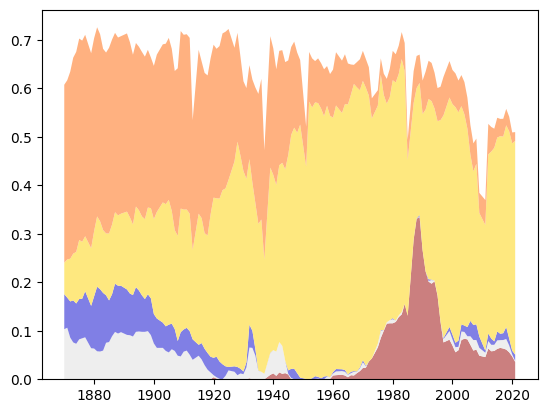

In [9]:
data = []

for year in range(1870, 2023):
    percentages = get_percentages_for_year(year, hex_array_2d, pixel_years, country_colors)
    data.append((year, percentages))

import polars as pl
df = pl.DataFrame(data, schema=["Year", "Percentages"])

df = df.unnest("Percentages").filter(pl.sum_horizontal(*[pl.col(c) for c in list(country_colors.keys())])>1e-2)
df = df.with_columns((1-pl.sum_horizontal(*[pl.col(c) for c in list(country_colors.keys())])).alias("Other"))

fig, ax = plt.subplots()
plot_order = ["JP", "DE", "FR", "US", "UK"]
ax.stackplot(df["Year"], [df[country] for country in plot_order], labels=plot_order, colors=[country_colors.get(c, "#cccccc") for c in plot_order])

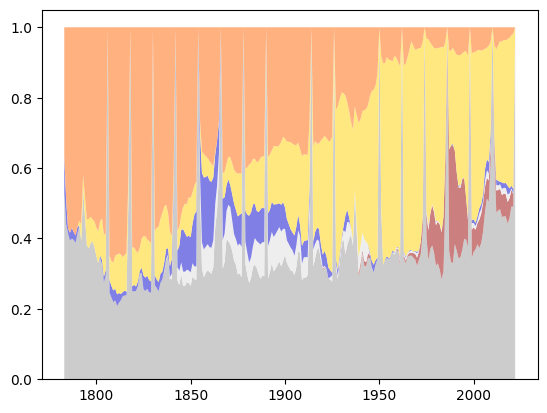

In [ ]:
"#ffb180"

In [130]:
hex_array_2d[40]

['#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb584',
 '#d98b5a',
 '#cf8150',
 '#ffb382',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb584',
 '#c27443',
 '#e59766',
 '#ffb483',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#ffb180',
 '#f

In [ ]:
country_colors = {
    "US": "#fee881",
    "UK": "#fdb462",
    "DE": "#eeeeee",
    "FR": "#807fe5",
    "JP": "#cb7f7f",
}


'#788ab9'